In [2]:
!pip install pywavelets scikit-learn matplotlib seaborn librosa reportlab requests

import os
import io
import requests
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import pywt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
DATASET_URL = "https://github.com/karolpiczak/ESC-50/archive/master.zip"
DATA_DIR = "./data_esc50"

def download_and_extract_esc50(download_dir):
    if not os.path.exists(download_dir):
        print("Descargando dataset ESC-50...")
        response = requests.get(DATASET_URL)
        with zipfile.ZipFile(io.BytesIO(response.content)) as z:
            z.extractall(download_dir)
        print("Descarga completada.")

download_and_extract_esc50(DATA_DIR)

# Configuración de rutas
base_path = os.path.join(DATA_DIR, "ESC-50-master")
csv_path = os.path.join(base_path, "meta", "esc50.csv")
audio_dir = os.path.join(base_path, "audio")

df = pd.read_csv(csv_path)

# Seleccionamos 5 clases variadas para un experimento claro y balanceado:
SELECTED_CATEGORIES = ['dog', 'chainsaw', 'rooster', 'rain', 'sea_waves']
df_filtered = df[df['category'].isin(SELECTED_CATEGORIES)].copy().reset_index(drop=True)

# Mapear nombres de categorías a índices
label_mapping = {category: idx for idx, category in enumerate(SELECTED_CATEGORIES)}
df_filtered['target_label'] = df_filtered['category'].map(label_mapping)

print(f"Total de muestras seleccionadas: {len(df_filtered)}")
print("Muestras por clase:\n", df_filtered['category'].value_counts())

Total de muestras seleccionadas: 200
Muestras por clase:
 category
dog          40
chainsaw     40
rain         40
rooster      40
sea_waves    40
Name: count, dtype: int64


In [4]:
# 3. EXTRACCIÓN DE CARACTERÍSTICAS DWT (Wavelets)

def extract_wavelet_features(file_path, wavelet='db1', level=5, target_sr=22050):
    """
    Carga el audio y extrae características de la descomposición DWT (Daubechies).
    """
    # Cargar audio a la frecuencia seleccionada
    y, sr = librosa.load(file_path, sr=target_sr, duration=5.0)

    # Aplicar DWT (Multiresolution Analysis)
    coeffs = pywt.wavedec(y, wavelet, level=level)

    features = []
    for c in coeffs:
        # Extraer métricas estadísticas clave por nivel
        features.extend([
            np.mean(c),
            np.std(c),
            np.var(c),
            np.sum(c ** 2)  # Energía
        ])

    return np.array(features)

print("\nExtrayendo características Wavelet de los archivos de audio...")
X = []
y = []

for idx, row in df_filtered.iterrows():
    audio_path = os.path.join(audio_dir, row['filename'])
    feat = extract_wavelet_features(audio_path, wavelet='db1', level=5)
    X.append(feat)
    y.append(row['target_label'])

X = np.array(X)
y = np.array(y)


Extrayendo características Wavelet de los archivos de audio...



>>> Accuracy en ESC-50: 68.00% <<<

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

         dog       0.78      0.70      0.74        10
    chainsaw       0.67      0.60      0.63        10
     rooster       0.56      0.50      0.53        10
        rain       0.82      0.90      0.86        10
   sea_waves       0.58      0.70      0.64        10

    accuracy                           0.68        50
   macro avg       0.68      0.68      0.68        50
weighted avg       0.68      0.68      0.68        50



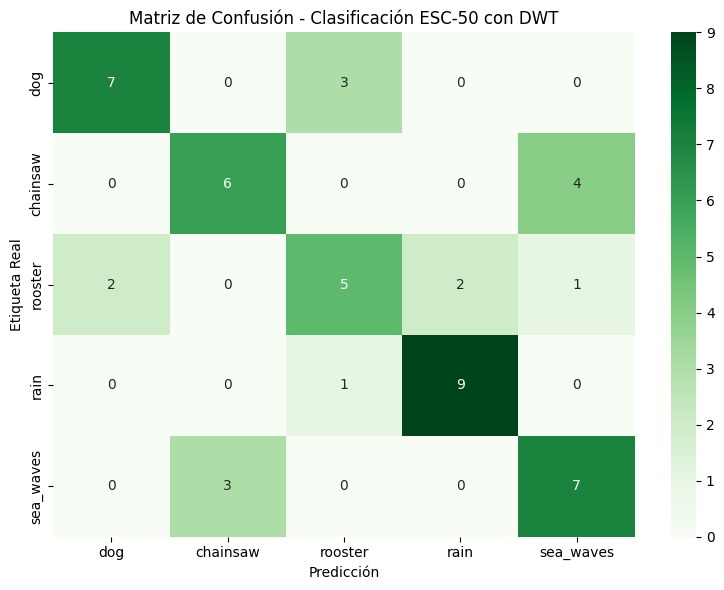

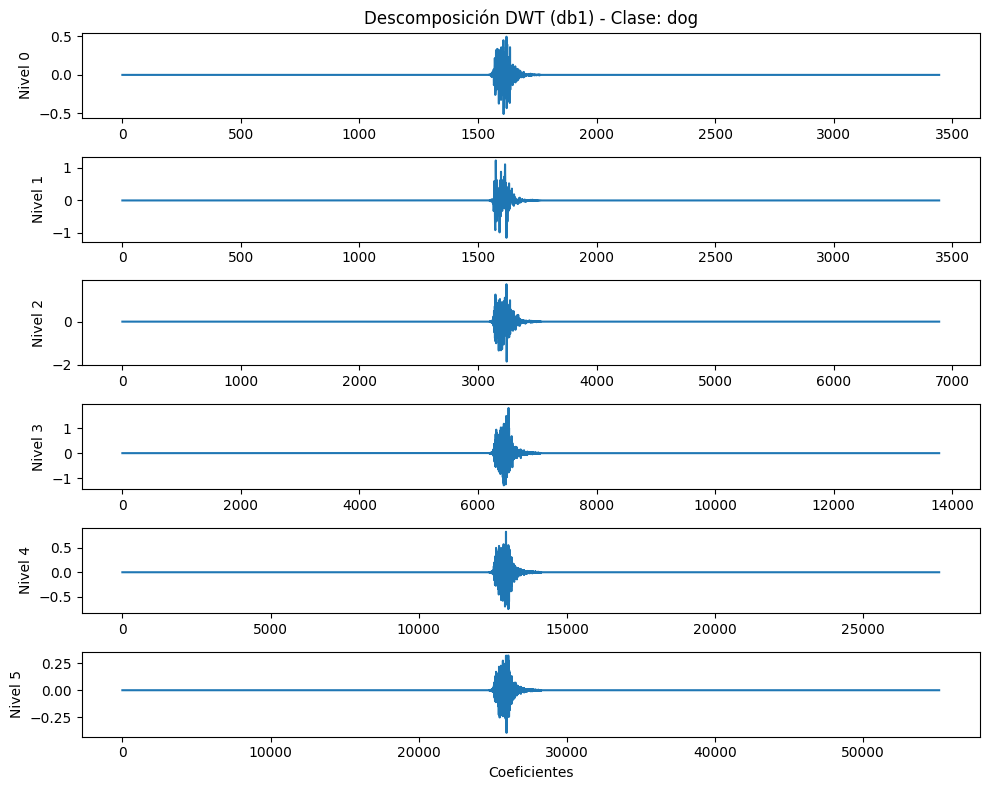

In [5]:
# 4. ENTRENAMIENTO Y EVALUACIÓN

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\n>>> Accuracy en ESC-50: {acc * 100:.2f}% <<<\n")

print("--- Reporte de Clasificación ---")
report_str = classification_report(y_test, y_pred, target_names=SELECTED_CATEGORIES)
print(report_str)

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=SELECTED_CATEGORIES,
            yticklabels=SELECTED_CATEGORIES)
plt.title('Matriz de Confusión - Clasificación ESC-50 con DWT')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.tight_layout()
plt.savefig('matriz_confusion_wavelets.png')
plt.show()

# Gráfico de descomposición de un audio de ejemplo
sample_path = os.path.join(audio_dir, df_filtered.iloc[0]['filename'])
sample_y, _ = librosa.load(sample_path, sr=22050, duration=5.0)
sample_coeffs = pywt.wavedec(sample_y, 'db1', level=5)

fig, axs = plt.subplots(len(sample_coeffs), 1, figsize=(10, 8))
axs[0].set_title(f"Descomposición DWT (db1) - Clase: {df_filtered.iloc[0]['category']}")
for i, coeff in enumerate(sample_coeffs):
    axs[i].plot(coeff)
    axs[i].set_ylabel(f'Nivel {i}')
plt.xlabel('Coeficientes')
plt.tight_layout()
plt.savefig('descomposicion_wavelet_ejemplo.png')
plt.show()